In [21]:
import numpy as np
import random
import functools
import yaml
import os
from deap import gp
from alpine.gp.gpsymbreg import GPSymbolicRegressor
import warnings
import ray
from sympy import symbols, lambdify, sin, sqrt, pprint, latex, cos, tanh
from IPython.display import display, Math
from ControllerComp import V_x, f, x, G, Q, R, safe_divideSR, compute_v_and_v_dot2

from Fitness import fitness
from PredictScoreFuncs import predict, score
import Functions
from SymFunctions import read_expression, DeapSimplifier
from V_Vdot_Calculations import compute_v_and_v_dot

import matplotlib.pyplot as plt

In [22]:
# Define the numerical grid (Domain)
x1_vals = np.linspace(-4, 4, 100)
x2_vals = np.linspace(-4, 4, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

In [3]:

def main():
    yamlfile = "Lyapunov.yaml"
    filename = yamlfile
    with open(filename) as config_file:
        config_file_data = yaml.safe_load(config_file)

    pset = gp.PrimitiveSetTyped(
        "MAIN",
        [
            float, float
        ],
        float,
    )
    
    pset.renameArguments(ARG0="x1", ARG1="x2")
    
    #pset.addPrimitive(one_minus_cos, (float,), float)

    def random_constant():
        return random.uniform(-10, 10)

    pset.addEphemeralConstant("rand", functools.partial(random_constant), float)

    #pset.addEphemeralConstant("rand", lambda: random.uniform(-10, 10), float)
    #pset.addTerminal(1, float) 
    
    penalty = config_file_data["gp"]["penalty"]
    common_data = {"penalty": penalty}

    gpsr = GPSymbolicRegressor(
        pset=pset,
        fitness=fitness.remote,
        error_metric=score.remote,
        predict_func=predict.remote,
        common_data=common_data,
        config_file_data=config_file_data,
        print_log=True,
        batch_size=100,
    )

    train_data = Functions.Dataset("true_data", [x1_vals, x2_vals], None)
    gpsr.fit(train_data)

    # Access and save the best individual
    best_expression = gpsr.best  # Save the best expression
    best_fitness = gpsr.train_fit_history[-1]  # Save the best fitness score

    # Write best expression to a file
    with open("best_expression.txt", "w") as file:
        file.write(f"Best Expression:\n{best_expression}\n")
        file.write(f"Best Fitness:\n{best_fitness}\n")

    print("Best Expression and Fitness saved to 'best_expression.txt'.")

    ray.shutdown()


if __name__ == "__main__":
    main()


2025-02-19 16:19:08,192	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Generating initial population(s)...
DONE.
 -= START OF EVOLUTION =- 
Evaluating initial population(s)...
(fitness pid=42549) Error in eval_MSE_sol: axis 1 is out of bounds for array of dimension 0
(fitness pid=42549) Error in eval_MSE_sol: axis 1 is out of bounds for array of dimension 0
(fitness pid=42549) Error in eval_MSE_sol: axis 1 is out of bounds for array of dimension 0
DONE.
   	     	            fitness            	              size             
   	     	-------------------------------	-------------------------------
gen	evals	min    	avg    	max    	std    	min	avg 	max	std    
1  	2000 	2319.02	16828.7	99746.1	15550.3	3  	16.1	77 	14.0135
Best individuals of this generation:
mul(mul(x2, x2), sub(4.824050703308185, x2))
(fitness pid=42570) Error in eval_MSE_sol: axis 1 is out of bounds for array of dimension 0 [repeated 17x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observab

In [23]:
expression = read_expression("best_expression.txt")
#read_expression("best_expression.txt") #+ '+ 73'
#'0.01875 * x2**2 + 0.73575 * (1 - cos(x1))'
#'x1**2 + x2**2'

simplified_expr = DeapSimplifier(expression)
display(Math(latex(simplified_expr)))

Original Expression: add(mul(add(x1, mul(mul(mul(mul(x2, 0.5993634517010875), 0.5993634517010875), 0.5993634517010875), 0.5993634517010875)), add(mul(add(mul(mul(mul(x2, 0.5993634517010875), 0.5993634517010875), 0.5993634517010875), add(x1, mul(x2, 0.5993634517010875))), 0.5993634517010875), sub(x1, x1))), mul(x1, x1))
Simplified Expression: x1**2 + (0.5993634517010875*x1 + 0.4882874441043963*x2)*(x1 + 0.1290508968693545*x2)


<IPython.core.display.Math object>

In [24]:
# Define symbolic variables
x1, x2 = symbols('x1 x2')
V_func = lambdify((x1, x2), simplified_expr, modules='numpy')
V_vals = V_func(X1, X2)

In [25]:
print(x1_vals.shape)

(100,)


In [26]:
_, V_grad_mag, V_dot_vals, lambda_vals, u_vals, u_vals2, u_mag, a_vals, b_nvals, b1 = compute_v_and_v_dot(V_vals, x1_vals, x2_vals)

In [27]:
V_violations = np.count_nonzero(V_vals < 0)
print(V_violations)

Vdot_violations = np.count_nonzero(V_dot_vals > 0)
print(Vdot_violations)

a_violations = np.count_nonzero((a_vals > 0) & (b_nvals < 0.000001))
print(a_violations)


0
0
0


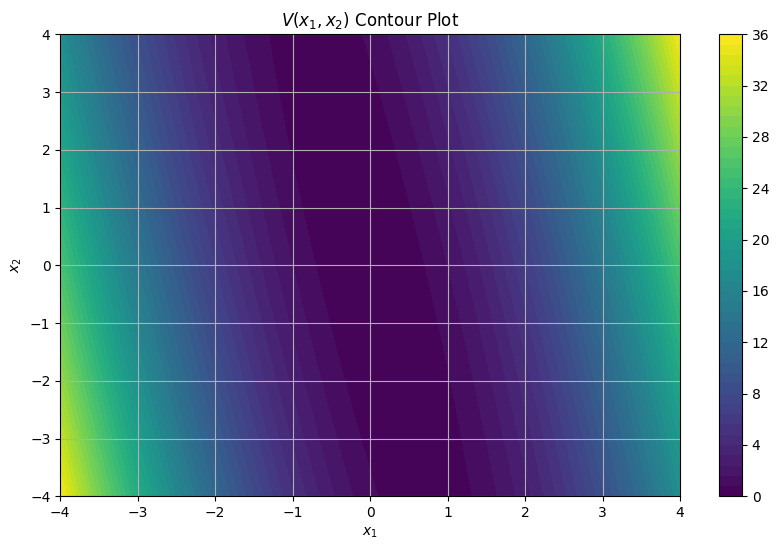

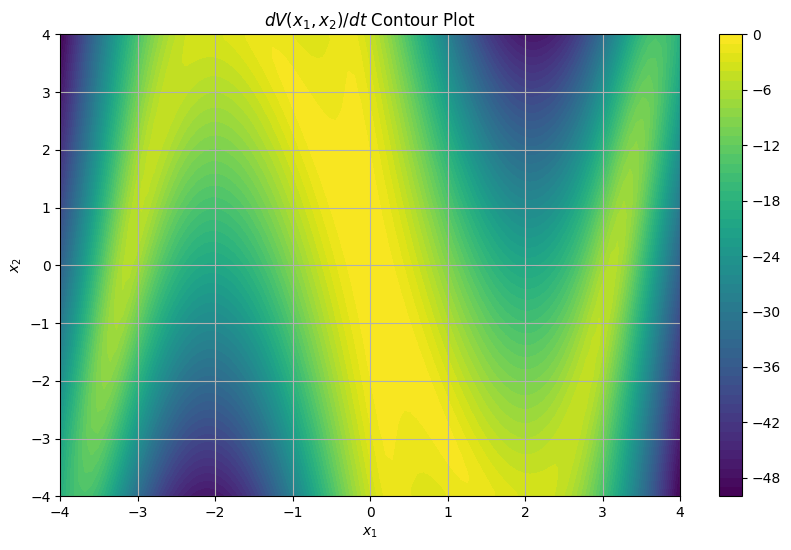

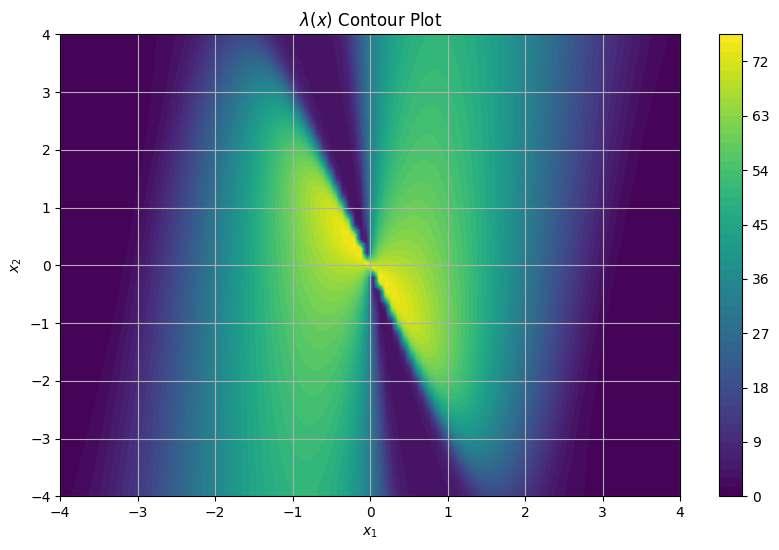

mean value of lambda:
24.41487445505134


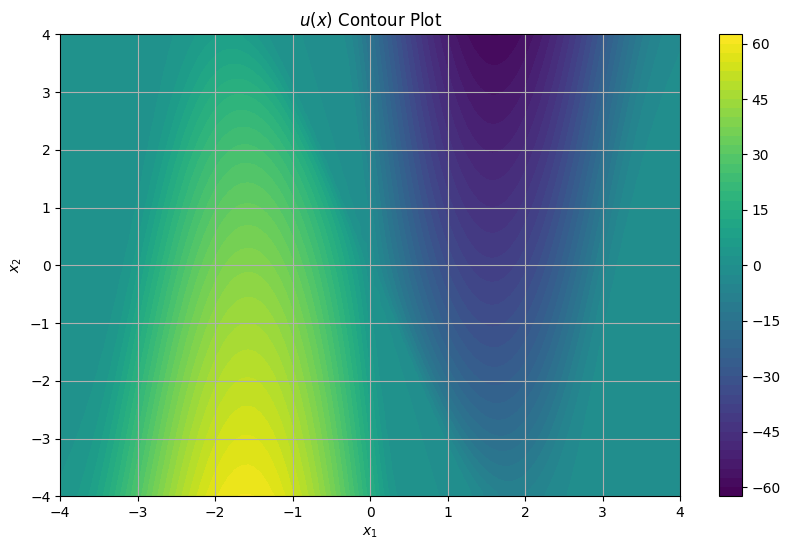

-4.0017766878008845e-15


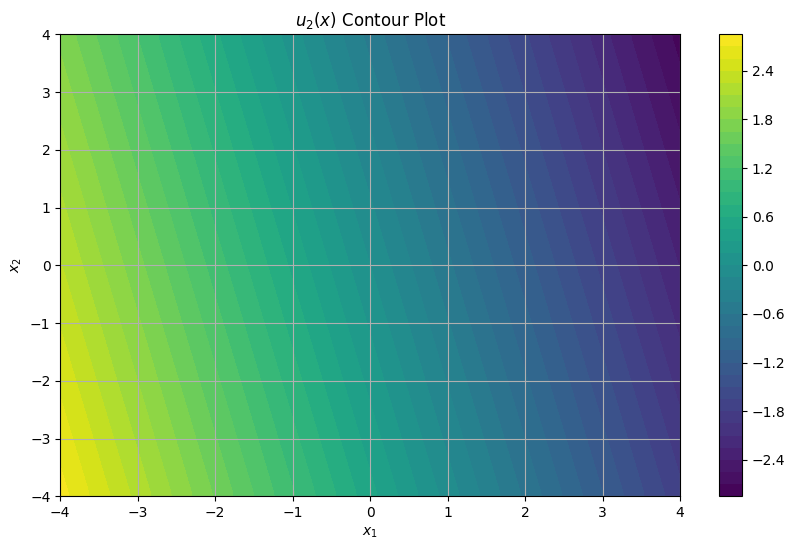

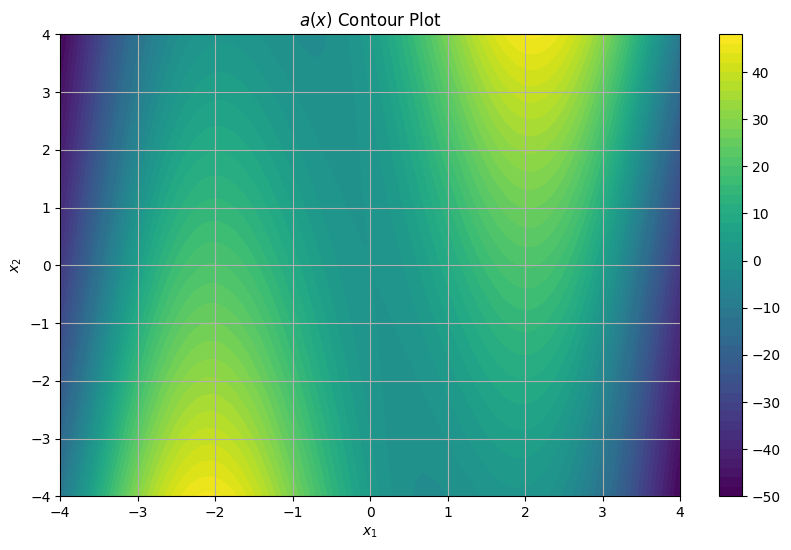

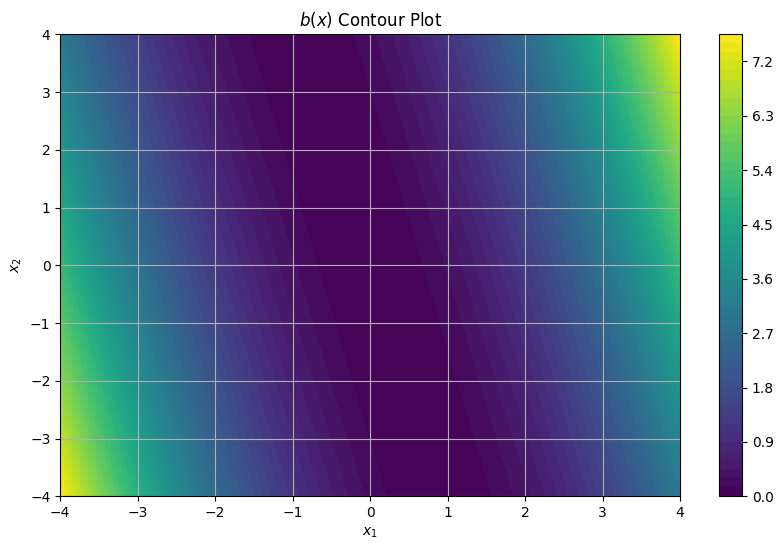

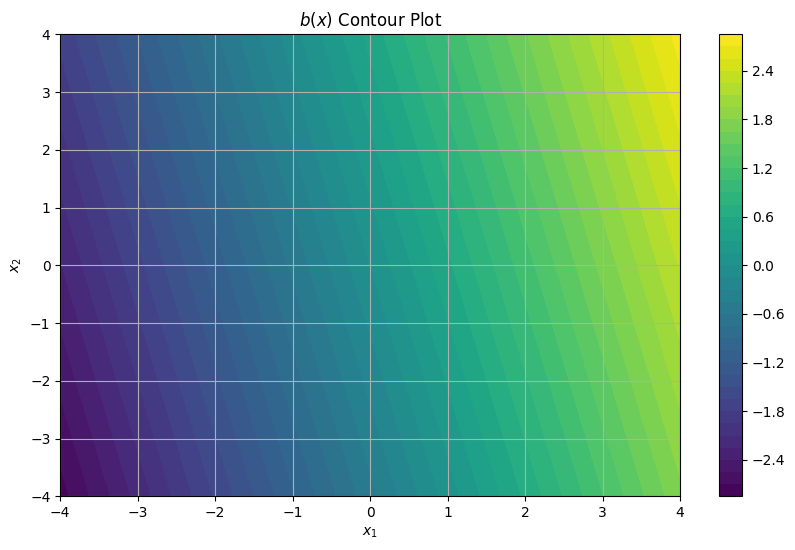

In [28]:
import matplotlib.pyplot as plt

X1 = x1_vals
X2 = x2_vals

# Plot V(x1, x2)
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x_1, x_2)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of V_x1
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_dot_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$d V(x_1, x_2) / dt$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of lambda_x
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, lambda_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\lambda(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

print('mean value of lambda:')
print(np.mean(lambda_vals))

# Plot the contour of u
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()
#levels=np.linspace(-10, 10, 50)
print(np.mean(u_vals))

# Plot the contour of u2
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u_2(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of a
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, a_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$a(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of b
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, b_nvals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of b1
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, b1, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

In [29]:
V = simplified_expr
x1, x2 = symbols('x1 x2')
V_grad = V_x(V, x1, x2)
x_vector = x(x1, x2)
f_vector = f(x1, x2)
G_matrix = G(x1, x2)
Q_matrix = Q(x1, x2)
R_matrix = R(x1, x2)

V_func, V_dot_func, lambda_func, u_func, u_func2, u_mag, b_norm_squared, b1 = compute_v_and_v_dot2(V)

print(b1)
u_func

0.5656358350971337*x1 + 0.1260278651834342*x2


3.125547967689886*(-0.5656358350971337*x1 - 0.1260278651834342*x2)*(x2*(3.198726903402175*x1 + 0.5656358350971337*x2) + (0.5656358350971337*x1 + 0.1260278651834342*x2)*(-2.66666666666667*x2 + 19.62*sin(x1)) + sqrt(0.3199438979460318*(x1 + 0.2228074272589044*x2)**2*(x1**2 + x2**2) + (x2*(3.198726903402175*x1 + 0.5656358350971337*x2) + (0.5656358350971337*x1 + 0.1260278651834342*x2)*(-2.66666666666667*x2 + 19.62*sin(x1)))**2))/(x1 + 0.2228074272589044*x2)**2

In [30]:
import sympy as sp
from sympy import simplify

# Define variables
x1, x2 = sp.symbols('x1 x2')

# Define expression (replace with your actual function)
expr = b1
expr = simplify(expr)
# Round coefficients to 2 decimal places
expr_rounded = expr.xreplace({n: round(n, 2) for n in expr.atoms(sp.Number)})

# Convert to LaTeX
latex_expr = sp.latex(expr_rounded)

# Print LaTeX expression
print(latex_expr)


0.57 x_{1} + 0.13 x_{2}


\frac{1.77 \left(x_{2} \left(3.2 x_{1} + 0.57 x_{2}\right) - \left(0.57 x_{1} + 0.13 x_{2}\right) \left(2.67 x_{2} - 19.62 \sin{\left(x_{1} \right)}\right) + \left(0.32 \left(x_{1} + 0.22 x_{2}\right)^{2} \left(x_{1}^{2} + x_{2}^{2}\right) + \left(x_{2} \left(3.2 x_{1} + 0.57 x_{2}\right) - \left(0.57 x_{1} + 0.13 x_{2}\right) \left(2.67 x_{2} - 19.62 \sin{\left(x_{1} \right)}\right)\right)^{2}\right)^{0.5}\right) \left(\left(x_{1} + 0.22 x_{2}\right)^{2}\right)^{0.5}}{\left(x_{1} + 0.22 x_{2}\right)^{2}}


- \frac{3.13 \left(0.57 x_{1} + 0.13 x_{2}\right) \left(x_{2} \left(3.2 x_{1} + 0.57 x_{2}\right) - \left(0.57 x_{1} + 0.13 x_{2}\right) \left(2.67 x_{2} - 19.62 \sin{\left(x_{1} \right)}\right) + \left(0.32 \left(x_{1} + 0.22 x_{2}\right)^{2} \left(x_{1}^{2} + x_{2}^{2}\right) + \left(x_{2} \left(3.2 x_{1} + 0.57 x_{2}\right) - \left(0.57 x_{1} + 0.13 x_{2}\right) \left(2.67 x_{2} - 19.62 \sin{\left(x_{1} \right)}\right)\right)^{2}\right)^{0.5}\right)}{\left(x_{1} + 0.22 x_{2}\right)^{2}}


In [31]:
b_norm_squared

0.3199438979460318*(x1 + 0.2228074272589044*x2)**2

In [32]:
print(V_dot_func)

x2*(3.198726903402175*x1 + 0.5656358350971337*x2) + 3.125547967689886*(-0.5656358350971337*x1 - 0.1260278651834342*x2)*(0.5656358350971337*x1 + 0.1260278651834342*x2)*(x2*(3.198726903402175*x1 + 0.5656358350971337*x2) + (0.5656358350971337*x1 + 0.1260278651834342*x2)*(-2.66666666666667*x2 + 19.62*sin(x1)) + sqrt(0.3199438979460318*(x1 + 0.2228074272589044*x2)**2*(x1**2 + x2**2) + (x2*(3.198726903402175*x1 + 0.5656358350971337*x2) + (0.5656358350971337*x1 + 0.1260278651834342*x2)*(-2.66666666666667*x2 + 19.62*sin(x1)))**2))/(x1 + 0.2228074272589044*x2)**2 + (0.5656358350971337*x1 + 0.1260278651834342*x2)*(-2.66666666666667*x2 + 19.62*sin(x1))


In [33]:
from sympy import symbols, Function, Matrix, Eq, dsolve
from SystemDynamics import f, G, Q, R
from NumSol import NumSol
import matplotlib.pyplot as plt

In [34]:
x1, x2 = symbols('x1 x2')

from sympy import symbols, lambdify, diff, Matrix, sin, cos, exp, log, sqrt, tanh

#u_func = -0.025467670686794*x1 - 0.19026288312708*x2
#u_func = 20 * tanh(-23.28 * x1 + -5.27 * x2)
#u_func = (-73*x1 - 40*x2)*(sqrt((73*x1 + 40*x2)**2*(x1**2 + x2**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))/(73*x1 + 40*x2)**2)
#u_func = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)

T = 4
x1_0, x2_0 = 1,1
#3,0 #-3, -3#-2.5, 0#1, 1# 4, 0
#t_vals, x1_vals, x2_vals = NumSol(u_func, T, x1_0, x2_0)

In [35]:
u_func_LQR = (-52.8710733230119*x1 - 26.0669049858921*x2)#/26.7
#-(14.1518 * x1 + 2.4269 * x2)
#-0.025467670686794*x1 - 0.19026288312708*x2
#-39.2654676706868*x1 - 6.64150428430349*x2
t_vals_L, x1_vals_L, x2_vals_L = NumSol(u_func_LQR, T, x1_0, x2_0, None)

u_func_NN = 20 * tanh(-23.28 * x1  -5.27 * x2) * 26.6 
t_vals_N, x1_vals_N, x2_vals_N = NumSol(u_func_NN, T, x1_0, x2_0, None)

#u_func_CLF = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)
u_func_CLF = u_func * 1
t_vals_C, x1_vals_C, x2_vals_C = NumSol(u_func_CLF, T, x1_0, x2_0, b_norm_squared)


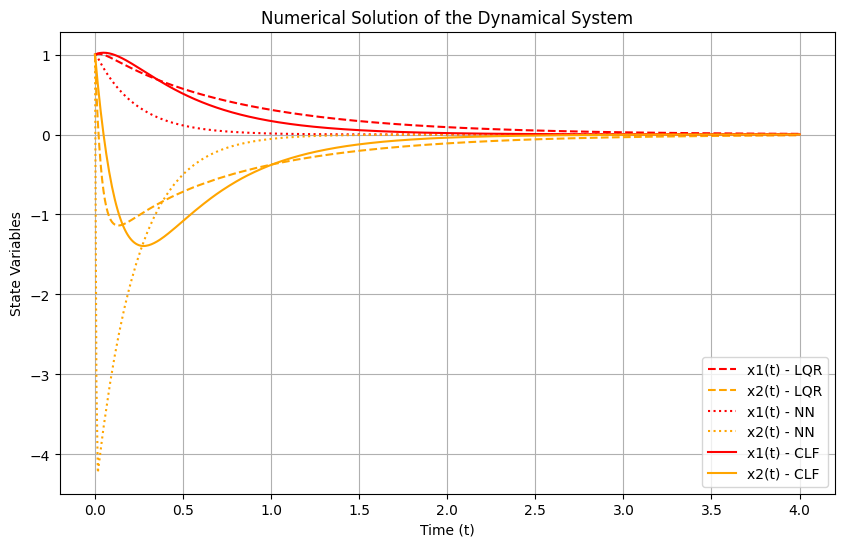

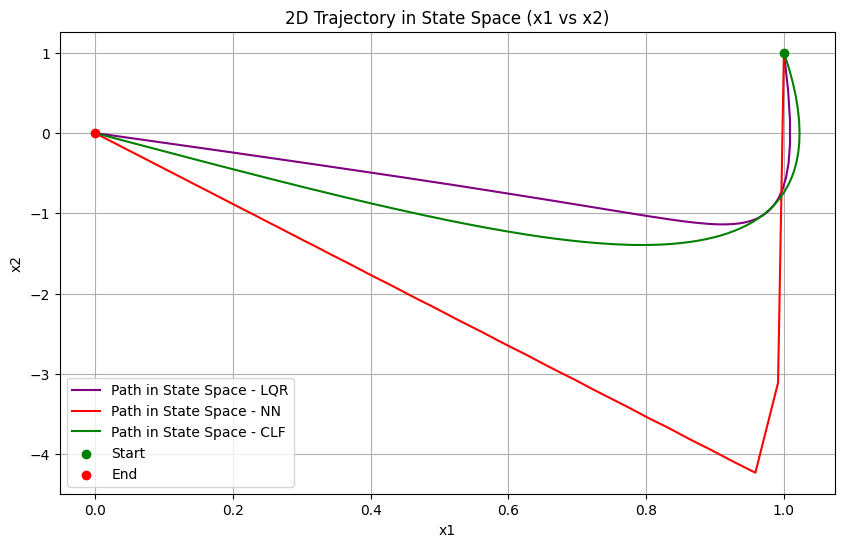

In [36]:
# Plot the solution
plt.figure(figsize=(10, 6))

plt.plot(t_vals_L, x1_vals_L, label="x1(t) - LQR", color="red", linestyle='--')
plt.plot(t_vals_L, x2_vals_L, label="x2(t) - LQR", color="orange", linestyle='--')

plt.plot(t_vals_N, x1_vals_N, label="x1(t) - NN", color="red", linestyle=':')
plt.plot(t_vals_N, x2_vals_N, label="x2(t) - NN", color="orange", linestyle=':')

plt.plot(t_vals_C, x1_vals_C, label="x1(t) - CLF", color="red")
plt.plot(t_vals_C, x2_vals_C, label="x2(t) - CLF", color="orange")
'''
plt.plot(time[0:10], x_list[0:10, 0], label="x1(t) - MCP", color="red", linestyle='-.')
plt.plot(time[0:10], x_list[0:10, 1], label="x2(t) - MPC", color="orange", linestyle='-.')
'''
plt.xlabel("Time (t)")
plt.ylabel("State Variables")
plt.legend()
plt.title("Numerical Solution of the Dynamical System")
plt.grid()
plt.show()


# Plot the 2D trajectory (state space path)
plt.figure(figsize=(10, 6))

plt.plot(x1_vals_L, x2_vals_L, label="Path in State Space - LQR", color="purple")
plt.plot(x1_vals_N, x2_vals_N, label="Path in State Space - NN", color="red")
plt.plot( x1_vals_C, x2_vals_C, label="Path in State Space - CLF", color="green")
'''
plt.plot(x_list[:, 0], x_list[:, 1], label="Path in State Space - MPC", color="b")
'''
plt.scatter(x1_0, x2_0, color="green", label="Start", zorder=5)  # Start point
plt.scatter(0, 0, color="red", label="End", zorder=5)  # End point

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Trajectory in State Space (x1 vs x2)")
plt.legend()
plt.grid()
plt.show()

In [37]:
from CostFunction import calculate_cost

# Calculate the cost
cost_LQR, cost_LQR1, cost_LQR2, u_val_LQR = calculate_cost(t_vals_L, x1_vals_L, x2_vals_L, u_func_LQR, None, 0)
print("Total cost for LQR:", cost_LQR, cost_LQR1, cost_LQR2)

cost_NN, cost_NN1, cost_NN2, u_val_NN = calculate_cost(t_vals_N, x1_vals_N, x2_vals_N, u_func_NN, None, 0)
print("Total cost for NN:", cost_NN, cost_NN1, cost_NN2)

cost_CLF, cost_CLF1, cost_CLF2, u_val_CLF = calculate_cost(t_vals_C, x1_vals_C, x2_vals_C, u_func_CLF, b_norm_squared, 0)
print("Total cost for CLF:", cost_CLF, cost_CLF1, cost_CLF2)

Total cost for LQR: [[1.57845481]] 1.0887878166077205 [[0.489667]]
Total cost for NN: [[8.71879004]] 2.3091187261440247 [[6.40967132]]
Total cost for CLF: [[1.73294559]] 1.3407224009884098 [[0.39222319]]


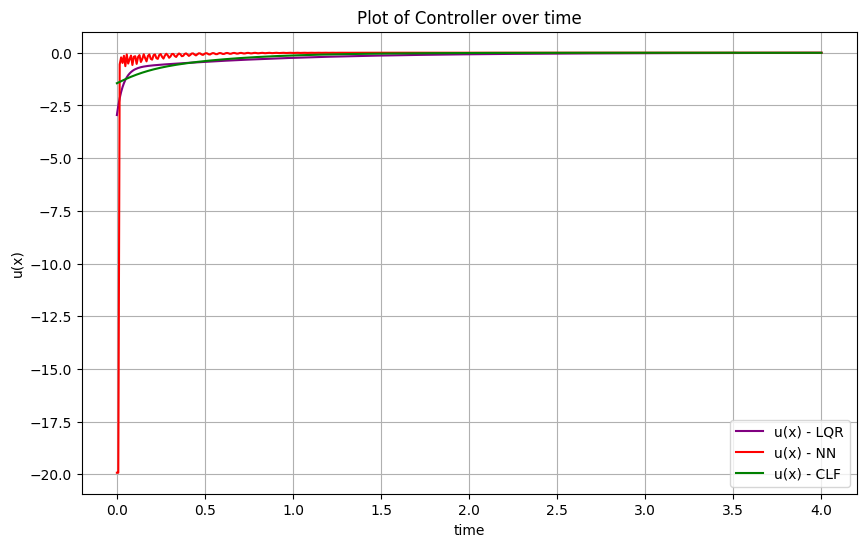

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals_C, u_val_LQR[:, 1]/26.7, label="u(x) - LQR", color="purple")
plt.plot(t_vals_C, u_val_NN[:, 1]/26.7, label="u(x) - NN", color="red")
plt.plot(t_vals_C, u_val_CLF[:, 1]/26.7, label="u(x) - CLF", color="green")
plt.xlabel("time")
plt.ylabel("u(x)")
plt.title("Plot of Controller over time")
plt.legend()
plt.grid()
plt.show()

In [39]:
x1_vals_C[-1]

0.0017723574856486576

In [ ]:
import pygame
import numpy as np
import imageio
import cv2

# Pygame Setup
WIDTH, HEIGHT = 600, 600
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
RED = (200, 0, 0)
FPS = 60  # Frame rate

# Length of pendulum in pixels (scaling factor)
l_pixels = 150

# Initialize pygame
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
clock = pygame.time.Clock()

# Video Writer Setup
output_video = "pendulum_animation.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec
video_writer = cv2.VideoWriter(output_video, fourcc, FPS, (WIDTH, HEIGHT))

# Prepare to Save Frames
frames = []  # List to store frames
durations = []  # List to store durations for each frame

# Simulation Variables
frame_index = 0  # Track current frame

# Simulation Loop
running = True
while running:
    screen.fill(WHITE)  # Clear screen
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # Update frame index
    if frame_index < len(t_vals_C) - 1:
        theta = x1_vals_C[frame_index]  # Get theta from precomputed solution
        frame_index += 1
    else:
        running = False  # Stop animation when done
        #frame_index = 0

    # Ensure theta is measured **from the vertical (UP)**
    theta_corrected = theta + np.pi  # Shift reference frame so upright is 0

    # Convert to screen coordinates (Y is flipped in pygame)
    origin = (WIDTH // 2, HEIGHT // 2)  # Pivot point (fixed point of pendulum)
    pend_x = int(origin[0] + l_pixels * np.sin(theta_corrected))  # X coordinate
    pend_y = int(origin[1] + l_pixels * np.cos(theta_corrected))  # Y coordinate (flipped)

    # Draw Pendulum
    pygame.draw.line(screen, BLACK, origin, (pend_x, pend_y), 5)  # Rod
    pygame.draw.circle(screen, RED, (pend_x, pend_y), 15)  # Mass

    pygame.display.flip()  # Update screen
    clock.tick(FPS)  # Maintain frame rate

    # Save frame (convert Pygame surface to numpy array)
    frame = pygame.surfarray.array3d(screen)  # Convert to NumPy array
    frame = np.fliplr(frame)  # Fix mirroring
    frame = np.rot90(frame)
    frame = np.ascontiguousarray(frame)  # Ensure correct memory alignment

    frames.append(frame)  # Store frame
    durations.append(1000 / FPS)  # Store duration (milliseconds per frame)

    # Convert to BGR for OpenCV (Pygame uses RGB)
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    # Write frame to video
    video_writer.write(frame_bgr)

pygame.quit()

# Save frames as GIF with precise timing
imageio.mimsave("pendulum_animation.gif", frames, duration=[d / 1000 for d in durations])
print("GIF saved as 'pendulum_animation.gif'.")

video_writer.release()  # Finalize video file
print(f"Video saved as '{output_video}' with {FPS} FPS.")